# 07 — CNN (EfficientNetB0)

> **Etapa 7 do pipeline.** Treina uma CNN sobre as imagens segmentadas (256×256)
> geradas no nb03 e compara o resultado com o melhor modelo clássico (XGBoost, F1=0.604).

## O que este notebook faz

1. Carrega as imagens `.npz` do nb03 e os splits do nb02
2. Monta `Dataset` e `DataLoader` com augmentation no treino
3. Fine-tune EfficientNetB0 em 2 estágios: cabeça → descongelar backbone
4. Avalia no val set a cada época, salva o melhor checkpoint
5. Avalia o melhor modelo no test set e compara com XGBoost

## O que este notebook NÃO faz

- Não usa features tabulares — só imagem pura (comparação limpa com o clássico)
- Não faz busca de hiperparâmetros — configuração razoável para o tamanho do dataset

## 1. Setup

In [1]:
from pathlib import Path
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
IMG_DIR  = ROOT / 'data' / 'processed' / 'images'
META_DIR = ROOT / 'data' / 'processed' / 'metadata'
OUT_DIR  = ROOT / 'models'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce GTX 1650 Ti
VRAM: 3.6 GB


## 2. Dataset

Carrega os `.npz` gerados no nb03 (`{image, mask, fallback}`) e os splits
do nb02. O `img_id` é a chave de ligação entre os dois.

**Augmentation no treino** — flips, rotação leve e jitter de cor. Não usamos
augmentation agressiva porque o dataset já é pequeno e queremos estabilidade
no treino. No val/test, apenas normalização ImageNet.

In [2]:
class SkinDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = row['img_id'].replace('.png', '')  # PAT_xxx_xxx_xxx
        data   = np.load(self.img_dir / f'{img_id}.npz')
        image  = data['image'].astype(np.float32) / 255.0  # [0,1]
        label  = int(row['y'])

        if self.transform:
            image = self.transform(image)
        else:
            # HWC → CHW
            image = torch.tensor(image).permute(2, 0, 1)

        return image, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Splits
train_df = pd.read_parquet(META_DIR / 'train.parquet')
val_df   = pd.read_parquet(META_DIR / 'val.parquet')
test_df  = pd.read_parquet(META_DIR / 'test.parquet')

le_target   = joblib.load(META_DIR / 'label_encoder.joblib')
class_names = list(le_target.classes_)
n_classes   = len(class_names)

train_ds = SkinDataset(train_df, IMG_DIR, train_transform)
val_ds   = SkinDataset(val_df,   IMG_DIR, val_transform)
test_ds  = SkinDataset(test_df,  IMG_DIR, val_transform)

# VRAM limitada (3.6 GB) — batch 16 é seguro para EfficientNetB0
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}')
print(f'classes: {class_names}')

train: 1470 | val: 368 | test: 460
classes: ['ACK', 'BCC', 'MEL', 'NEV', 'SCC', 'SEK']


## 3. Modelo — EfficientNetB0

Fine-tune em **2 estágios**:

1. **Estágio 1 (cabeça)** — backbone congelado, treina só o classificador final.
   Garante que os pesos ImageNet não sejam destruídos no início do treino.
2. **Estágio 2 (fine-tune)** — descongelar o backbone com learning rate menor.
   Permite que as features visuais se especializem para lesões cutâneas.

**Loss ponderada** — mesmo esquema do XGBoost: cada classe recebe peso
inversamente proporcional à sua frequência no treino.

In [3]:
class_weights = joblib.load(META_DIR / 'class_weights.joblib')
weights_tensor = torch.tensor(
    [class_weights[i] for i in range(n_classes)], dtype=torch.float32
).to(DEVICE)

def build_model():
    model = models.efficientnet_b0(weights='IMAGENET1K_V1')
    # Substitui o classificador final
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, n_classes)
    )
    return model.to(DEVICE)

def freeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = False

def unfreeze_backbone(model):
    for param in model.features.parameters():
        param.requires_grad = True

model = build_model()
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

n_params = sum(p.numel() for p in model.parameters())
print(f'EfficientNetB0 — {n_params/1e6:.1f}M parâmetros')
print(f'Loss: CrossEntropy ponderada | Device: {DEVICE}')

EfficientNetB0 — 4.0M parâmetros
Loss: CrossEntropy ponderada | Device: cuda


## 4. Loop de treino

In [4]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    y_pred = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    mel_idx = class_names.index('MEL')
    from sklearn.metrics import recall_score
    return {
        'f1_macro':   f1_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_mel': recall_score(y_true, y_pred, average=None, zero_division=0)[mel_idx],
        'y_pred':     y_pred,
        'y_true':     y_true,
    }


def run_stage(model, loader_tr, loader_val, optimizer, scheduler, n_epochs, stage_name):
    best_f1, best_state = 0, None
    history = []
    for epoch in range(1, n_epochs + 1):
        t0   = time.time()
        loss = train_epoch(model, loader_tr, optimizer)
        res  = evaluate(model, loader_val)
        scheduler.step()
        elapsed = time.time() - t0
        history.append({'epoch': epoch, 'loss': loss, **{k: v for k, v in res.items() if k != 'y_pred' and k != 'y_true'}})
        flag = ''
        if res['f1_macro'] > best_f1:
            best_f1   = res['f1_macro']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            flag = ' ← best'
        print(f'[{stage_name}] ep{epoch:02d} loss={loss:.4f} f1={res["f1_macro"]:.4f} mel={res["recall_mel"]:.3f} ({elapsed:.0f}s){flag}')
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    return history

## 5. Estágio 1 — treinar só a cabeça (5 épocas)

Backbone congelado, apenas o classificador final aprende.
Objetivo: adaptar os pesos da camada final ao problema antes de
descongelar o backbone.

In [5]:
freeze_backbone(model)

optimizer1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler1 = optim.lr_scheduler.CosineAnnealingLR(optimizer1, T_max=5)

hist1 = run_stage(model, train_loader, val_loader, optimizer1, scheduler1,
                  n_epochs=5, stage_name='S1-head')

[S1-head] ep01 loss=1.6721 f1=0.3134 mel=0.000 (32s) ← best
[S1-head] ep02 loss=1.4652 f1=0.3298 mel=0.111 (29s) ← best
[S1-head] ep03 loss=1.3504 f1=0.3904 mel=0.222 (21s) ← best
[S1-head] ep04 loss=1.3076 f1=0.3410 mel=0.000 (21s)
[S1-head] ep05 loss=1.2798 f1=0.3727 mel=0.111 (21s)


## 6. Estágio 2 — fine-tune do backbone (10 épocas)

Descongelar o backbone com learning rate 10× menor que o estágio 1.
O backbone já tem boas features ImageNet — o fine-tune suave
especializa para lesões sem destruir o conhecimento pré-treinado.

In [6]:
unfreeze_backbone(model)

optimizer2 = optim.Adam(model.parameters(), lr=1e-4)
scheduler2 = optim.lr_scheduler.CosineAnnealingLR(optimizer2, T_max=10)

hist2 = run_stage(model, train_loader, val_loader, optimizer2, scheduler2,
                  n_epochs=10, stage_name='S2-full')

# Salva o melhor modelo
cnn_path = OUT_DIR / 'efficientnetb0_best.pt'
torch.save(model.state_dict(), cnn_path)
print(f'\nModelo salvo: {cnn_path}')

[S2-full] ep01 loss=1.2166 f1=0.4348 mel=0.333 (30s) ← best
[S2-full] ep02 loss=0.9781 f1=0.4946 mel=0.333 (36s) ← best
[S2-full] ep03 loss=0.8271 f1=0.5531 mel=0.556 (35s) ← best
[S2-full] ep04 loss=0.7437 f1=0.5464 mel=0.556 (27s)
[S2-full] ep05 loss=0.6638 f1=0.5708 mel=0.667 (36s) ← best
[S2-full] ep06 loss=0.6371 f1=0.5401 mel=0.444 (36s)
[S2-full] ep07 loss=0.5454 f1=0.5634 mel=0.444 (36s)
[S2-full] ep08 loss=0.5345 f1=0.5368 mel=0.444 (26s)
[S2-full] ep09 loss=0.5423 f1=0.5558 mel=0.667 (19s)
[S2-full] ep10 loss=0.5141 f1=0.5569 mel=0.556 (19s)

Modelo salvo: /home/icaro/Documentos/projeto_pad_ufes/models/efficientnetb0_best.pt


## 7. Curva de aprendizado

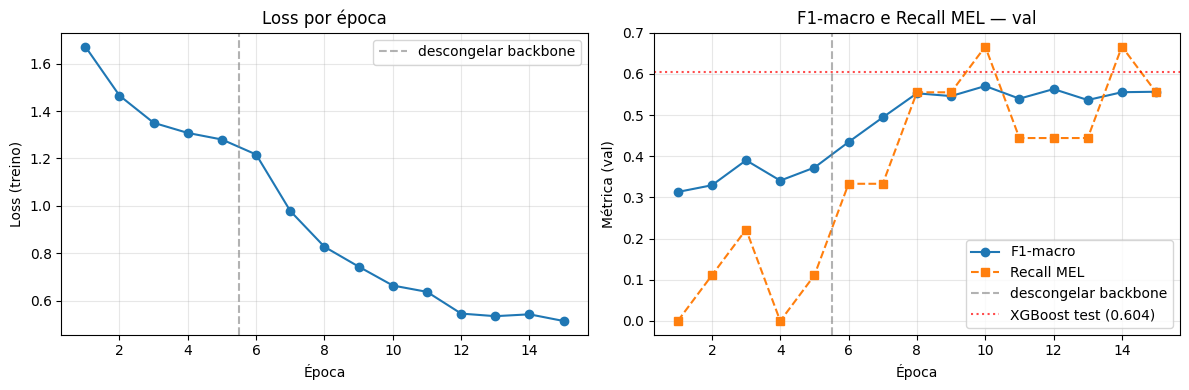

In [7]:
history = hist1 + [{**h, 'epoch': h['epoch'] + 5} for h in hist2]
df_hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_hist['epoch'], df_hist['loss'], marker='o')
axes[0].axvline(5.5, color='gray', linestyle='--', alpha=0.6, label='descongelar backbone')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss (treino)')
axes[0].set_title('Loss por época'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_hist['epoch'], df_hist['f1_macro'], marker='o', label='F1-macro')
axes[1].plot(df_hist['epoch'], df_hist['recall_mel'], marker='s', linestyle='--', label='Recall MEL')
axes[1].axvline(5.5, color='gray', linestyle='--', alpha=0.6, label='descongelar backbone')
axes[1].axhline(0.604, color='red', linestyle=':', alpha=0.7, label='XGBoost test (0.604)')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Métrica (val)')
axes[1].set_title('F1-macro e Recall MEL — val'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Avaliação final no TEST

O melhor checkpoint do estágio 2 (maior F1-macro no val) é avaliado
no test set — única vez que o test é tocado.

In [8]:
res_test = evaluate(model, test_loader)

print('=' * 60)
print('EfficientNetB0 — TEST')
print('=' * 60)
print(f'F1-macro    : {res_test["f1_macro"]:.4f}')
print(f'Recall MEL  : {res_test["recall_mel"]:.4f}  ← classe crítica')
print()
print(classification_report(res_test['y_true'], res_test['y_pred'],
                             target_names=class_names, zero_division=0, digits=3))

# Comparação com XGBoost
print('=' * 60)
print('Comparação CNN × XGBoost (test)')
print('=' * 60)
print(f'{"":20} {"F1-macro":>10} {"Recall MEL":>12}')
print(f'{"XGBoost":20} {0.6039:>10.4f} {0.4000:>12.4f}')
print(f'{"EfficientNetB0":20} {res_test["f1_macro"]:>10.4f} {res_test["recall_mel"]:>12.4f}')

EfficientNetB0 — TEST
F1-macro    : 0.5359
Recall MEL  : 0.6000  ← classe crítica

              precision    recall  f1-score   support

         ACK      0.774     0.610     0.682       146
         BCC      0.695     0.621     0.656       169
         MEL      0.333     0.600     0.429        10
         NEV      0.574     0.796     0.667        49
         SCC      0.250     0.462     0.324        39
         SEK      0.528     0.404     0.458        47

    accuracy                          0.600       460
   macro avg      0.526     0.582     0.536       460
weighted avg      0.645     0.600     0.612       460

Comparação CNN × XGBoost (test)
                       F1-macro   Recall MEL
XGBoost                  0.6039       0.4000
EfficientNetB0           0.5359       0.6000


## 9. Matriz de confusão — TEST

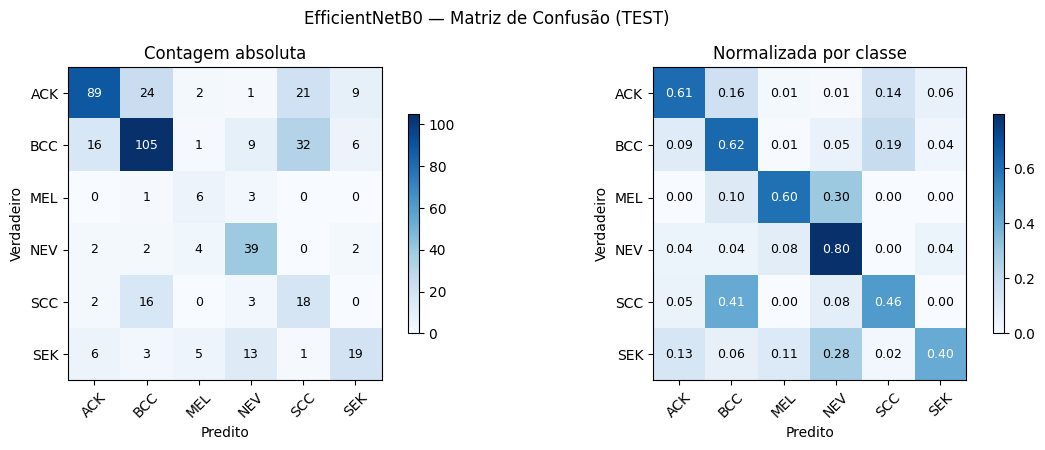

In [9]:
cm = confusion_matrix(res_test['y_true'], res_test['y_pred'])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, matrix, title, fmt in [
    (axes[0], cm,      'Contagem absoluta', 'd'),
    (axes[1], cm_norm, 'Normalizada por classe', '.2f'),
]:
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predito'); ax.set_ylabel('Verdadeiro')
    ax.set_title(title)
    for i in range(6):
        for j in range(6):
            color = 'white' if matrix[i,j] > matrix.max()*0.5 else 'black'
            ax.text(j, i, format(matrix[i,j], fmt), ha='center', va='center',
                    color=color, fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('EfficientNetB0 — Matriz de Confusão (TEST)', fontsize=12)
plt.tight_layout()
plt.show()